导入数据

In [1]:
import json

DATA_INFO_PATH = r"C:/Users/yyy/Desktop/course project/BCIC2A/dataset_info_fixed.json"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)

=== Dataset Intro ===
Categories: ['left', 'right', 'foot', 'tongue']
Channels (count): 22
Channels: ['FZ', 'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'P1', 'PZ', 'P2', 'POZ']
Target Sampling Rate (Hz): 200.0
Window Size (sec): 1.0


## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。

In [2]:
import h5py
import numpy as np
DATA_NAME = "BCIC2A"
INDEX_PATH_TRAIN = r"C:/Users/yyy/Desktop/course project/BCIC2A/train.h5"
INDEX_PATH_VAL = r"C:/Users/yyy/Desktop/course project/BCIC2A/val.h5"
INDEX_PATH_TEST = r"C:/Users/yyy/Desktop/course project/BCIC2A/test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))
    print(INDEX_PATH_TEST)

keys: ['X', 'y']
x dtype: float32
x shape: (720, 22, 800)
y dtype: int64
y shape: (720,)
unique: [0 1 2 3]
C:/Users/yyy/Desktop/course project/BCIC2A/test_x_only.h5


In [3]:
import os

print(os.path.exists(INDEX_PATH_TEST))
print(os.path.getsize(INDEX_PATH_TEST))

True
25346048


## 模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline

In [4]:
import torch
import torch.nn as nn


class EEGNet(nn.Module):
    def __init__(
        self,
        chans,
        time_point=800,
        num_classes=4,
        f1=8,
        d=2,
        pk1=4,
        pk2=8,
        dp=0.5,
        max_norm1=1,
        norm=nn.Identity()
    ):
        super().__init__()

        f2 = f1 * d
        self.norm = norm

       # Temporal Convolution
        self.block1 = nn.Sequential(
            nn.Conv2d(
                1, f1,
                kernel_size=(1, 100),  # <--- 修改：从 64 改为 100
                padding=(0, 50),       # <--- 修改：从 32 改为 50
                bias=False
            ),
            nn.BatchNorm2d(f1)
        )

        # Depthwise Spatial Convolution
        self.block2 = nn.Sequential(
            nn.Conv2d(
                f1,
                d * f1,
                kernel_size=(chans, 1),
                groups=f1,
                bias=False
            ),
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp)
        )

        # Separable Convolution
        self.block3 = nn.Sequential(
            nn.Conv2d(
                d * f1,
                f2,
                kernel_size=(1, 16),
                groups=f2,
                padding=(0, 8),
                bias=False
            ),
            nn.Conv2d(
                f2,
                f2,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp)
        )

        # Max norm
        self._apply_max_norm(self.block2[0], max_norm1)

        # 自动计算特征维度
        with torch.no_grad():
            dummy = torch.zeros(1, chans, time_point)  # (B, C, T)
            dummy = self._forward_features(dummy)
            self.embed_dim = dummy.shape[1]

        print("EEGNet embed_dim =", self.embed_dim)

        # 分类层
        self.classifier = nn.Linear(self.embed_dim, num_classes)

    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if "weight" in name:
                param.data = torch.renorm(
                    param.data,
                    p=2,
                    dim=0,
                    maxnorm=max_norm
                )

    def _forward_features(self, x):
        """
        x: (B, C, T)
        """
        x = self.norm(x)

        # 如果输入单个样本 (C, T)
        if x.dim() == 2:
            x = x.unsqueeze(0)

        # (B, C, T) -> (B, 1, C, T)
        x = x.unsqueeze(1)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = x.flatten(start_dim=1)
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = self.classifier(x)
        return x

## 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。

Using device: cuda
Using seed: 7
EEGNet embed_dim = 736
Epoch [001/1000] | Train Loss: 1.4214 | Train Acc: 0.2611 | Val Loss: 1.3509 | Val Acc: 0.3417 | LR: 0.001000
✅ Best model updated at epoch 1 | Val Acc = 0.3417
Epoch [002/1000] | Train Loss: 1.3858 | Train Acc: 0.3097 | Val Loss: 1.3112 | Val Acc: 0.4139 | LR: 0.001000
✅ Best model updated at epoch 2 | Val Acc = 0.4139
Epoch [003/1000] | Train Loss: 1.3484 | Train Acc: 0.3681 | Val Loss: 1.2835 | Val Acc: 0.4389 | LR: 0.001000
✅ Best model updated at epoch 3 | Val Acc = 0.4389
Epoch [004/1000] | Train Loss: 1.3076 | Train Acc: 0.3903 | Val Loss: 1.2520 | Val Acc: 0.4833 | LR: 0.001000
✅ Best model updated at epoch 4 | Val Acc = 0.4833
Epoch [005/1000] | Train Loss: 1.2998 | Train Acc: 0.3792 | Val Loss: 1.2408 | Val Acc: 0.5000 | LR: 0.001000
✅ Best model updated at epoch 5 | Val Acc = 0.5000
Epoch [006/1000] | Train Loss: 1.2729 | Train Acc: 0.4222 | Val Loss: 1.2299 | Val Acc: 0.4861 | LR: 0.001000
EarlyStopping Counter: 1/80
E

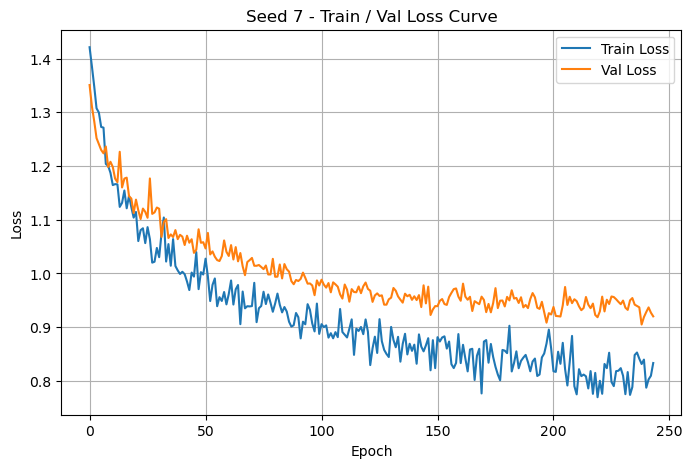

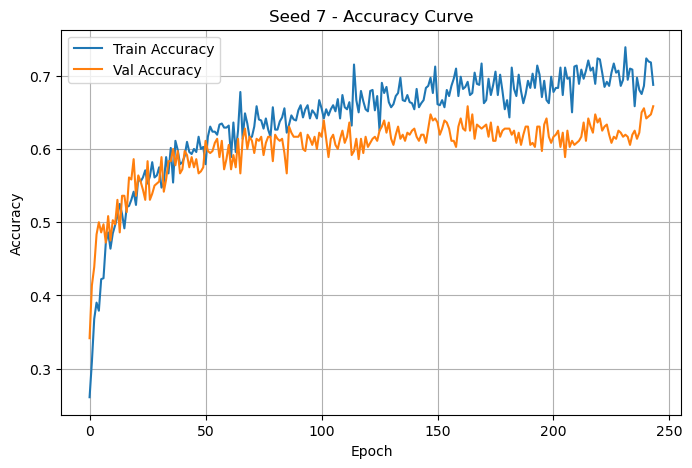


Final Validation Result
Final Val Loss: 0.9510
Final Val Acc : 0.6583

Classification Report:

              precision    recall  f1-score   support

   Left Hand     0.6701    0.7222    0.6952        90
  Right Hand     0.6292    0.6222    0.6257        90
        Foot     0.6250    0.6667    0.6452        90
      Tongue     0.7179    0.6222    0.6667        90

    accuracy                         0.6583       360
   macro avg     0.6606    0.6583    0.6582       360
weighted avg     0.6606    0.6583    0.6582       360

--------------------------------------------------
Confusion Matrix:

[[65 10  9  6]
 [12 56 15  7]
 [12  9 60  9]
 [ 8 14 12 56]]
--------------------------------------------------
Test input shape : torch.Size([1, 22, 800])
Test output shape: torch.Size([1, 4])
Predicted class  : 3


In [5]:
import h5py
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix

from TEST_DATASET import TrainDataset, TestDataset


# =====================================================
# 固定随机种子
# =====================================================
def set_seed(seed=7):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 7
set_seed(SEED)


# =====================================================
# Gaussian noise 增强
# =====================================================
def add_gaussian_noise(x, noise_std=0.02):
    """
    x shape: (B, C, T)
    """
    noise = torch.randn_like(x) * noise_std
    return x + noise


# =====================================================
# Channel dropout 增强
# =====================================================
def channel_dropout(x, drop_prob=0.05):
    """
    x shape: (B, C, T)
    随机丢弃部分 EEG 通道。
    """
    if drop_prob <= 0:
        return x

    mask = torch.rand(
        x.shape[0],
        x.shape[1],
        1,
        device=x.device
    ) > drop_prob

    return x * mask


# =====================================================
# Random crop：训练用
# =====================================================
def random_crop(x, crop_len=750):
    """
    x shape: (B, C, T)
    从 800 点随机裁成 750 点。
    """
    T = x.shape[-1]

    if T == crop_len:
        return x

    start = random.randint(0, T - crop_len)
    end = start + crop_len

    return x[:, :, start:end]


# =====================================================
# Crop TTA：验证 / 测试用
# =====================================================
def crop_tta_predict(model, x, crop_len=750, starts=None):
    """
    x shape: (B, C, T)
    对同一个样本取多个 crop，平均 logits。
    """
    if starts is None:
        starts = [0, 25, 50]

    logits_sum = 0

    for start in starts:
        end = start + crop_len
        x_crop = x[:, :, start:end]

        logits_sum += model(x_crop)

    return logits_sum / len(starts)


# =====================================================
# 参数
# =====================================================
CHANNELS = 22
CLASSES = 4

BATCH_SIZE = 32
EPOCHS = 1000

LR = 1e-3
WEIGHT_DECAY = 5e-4

PATIENCE = 80
MIN_DELTA = 0.001

MIN_LR = 1e-6

CROP_LEN = 750

# 验证 / 测试统一使用 11 个 crop
CROP_STARTS = [
    0, 5, 10, 15, 20,
    25, 30, 35, 40, 45, 50
]

NOISE_STD = 0.02
CHANNEL_DROP_PROB = 0.05

SAVE_PATH = "best_EEGNet_seed7.pth"


# =====================================================
# 设备
# =====================================================
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)
print("Using seed:", SEED)


# =====================================================
# 数据
# =====================================================
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)
test_ds = TestDataset(INDEX_PATH_TEST)


# =====================================================
# 标准化：只用 train 统计量
# 注意：先标准化 800 点，再在训练 / 验证时裁成 750 点
# =====================================================
mean = train_ds.x.mean(dim=(0, 2), keepdim=True)
std = train_ds.x.std(dim=(0, 2), keepdim=True) + 1e-6

train_ds.x = (train_ds.x - mean) / std
val_ds.x = (val_ds.x - mean) / std
test_ds.x = (test_ds.x - mean) / std


# =====================================================
# DataLoader
# 注意：shuffle 也用固定 generator
# =====================================================
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    generator=generator
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False
)


# =====================================================
# 模型
# 注意：time_point = CROP_LEN = 750
# =====================================================
model = EEGNet(
    chans=CHANNELS,
    time_point=CROP_LEN,
    num_classes=CLASSES,
    f1=16,
    d=2,
    pk1=4,
    pk2=8,
    dp=0.5
)

model = model.to(device)


# =====================================================
# Loss
# =====================================================
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.03
)


# =====================================================
# Optimizer
# =====================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)


# =====================================================
# Scheduler：CosineAnnealingLR
# =====================================================
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=MIN_LR
)


# =====================================================
# 记录
# =====================================================
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_acc = 0.0
best_epoch = 0
early_stop_counter = 0

best_model_state = copy.deepcopy(
    model.state_dict()
)


# =====================================================
# 训练循环
# =====================================================
for epoch in range(EPOCHS):

    # =================================================
    # Train
    # =================================================
    model.train()

    train_loss_sum = 0.0
    train_correct = 0
    train_num = 0

    for data, label in train_loader:

        data = data.to(device)
        label = label.to(device)

        # ---------------------------------------------
        # 训练增强：Gaussian noise + channel dropout
        # ---------------------------------------------
        data = add_gaussian_noise(
            data,
            noise_std=NOISE_STD
        )

        data = channel_dropout(
            data,
            drop_prob=CHANNEL_DROP_PROB
        )

        # ---------------------------------------------
        # Random crop: 800 -> 750
        # ---------------------------------------------
        data = random_crop(
            data,
            crop_len=CROP_LEN
        )

        optimizer.zero_grad()

        output = model(data)

        loss = criterion(
            output,
            label
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        batch_size = label.size(0)

        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

        pred = torch.argmax(
            output,
            dim=1
        )

        train_correct += (
            pred == label
        ).sum().item()

    epoch_train_loss = train_loss_sum / train_num
    epoch_train_acc = train_correct / train_num

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # =================================================
    # Validation
    # =================================================
    model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for val_data, val_label in val_loader:

            val_data = val_data.to(device)
            val_label = val_label.to(device)

            val_output = crop_tta_predict(
                model=model,
                x=val_data,
                crop_len=CROP_LEN,
                starts=CROP_STARTS
            )

            val_loss = criterion(
                val_output,
                val_label
            )

            batch_size = val_label.size(0)

            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(
                val_output,
                dim=1
            )

            val_correct += (
                val_pred == val_label
            ).sum().item()

            all_preds.extend(
                val_pred.cpu().numpy()
            )

            all_labels.extend(
                val_label.cpu().numpy()
            )

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # =================================================
    # Scheduler step
    # =================================================
    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    # =================================================
    # 保存 Val Acc 最好的 epoch
    # =================================================
    if epoch_val_acc > best_val_acc + MIN_DELTA:

        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1
        early_stop_counter = 0

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            SAVE_PATH
        )

        print(
            f"✅ Best model updated at epoch {best_epoch} | "
            f"Val Acc = {best_val_acc:.4f}"
        )

    else:

        early_stop_counter += 1

        print(
            f"EarlyStopping Counter: "
            f"{early_stop_counter}/{PATIENCE}"
        )

        if early_stop_counter >= PATIENCE:
            print("\n🛑 Early Stopping Triggered!")
            break


# =====================================================
# 加载最佳模型
# =====================================================
model.load_state_dict(
    torch.load(
        SAVE_PATH,
        map_location=device
    )
)

model.eval()


# =====================================================
# 输出最佳结果
# =====================================================
print("\n" + "=" * 60)
print(f"Seed              : {SEED}")
print(f"Best Epoch        : {best_epoch}")
print(f"Best Val Accuracy : {best_val_acc:.4f}")
print(f"Saved Path        : {SAVE_PATH}")
print("=" * 60)


# =====================================================
# Loss 曲线
# =====================================================
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Seed 7 - Train / Val Loss Curve")
plt.legend()
plt.grid(True)
plt.show()


# =====================================================
# Accuracy 曲线
# =====================================================
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Seed 7 - Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()


# =====================================================
# 最佳模型在验证集上重新评估
# =====================================================
all_preds = []
all_labels = []

val_loss_sum = 0.0
val_correct = 0
val_num = 0

with torch.no_grad():

    for val_data, val_label in val_loader:

        val_data = val_data.to(device)
        val_label = val_label.to(device)

        val_output = crop_tta_predict(
            model=model,
            x=val_data,
            crop_len=CROP_LEN,
            starts=CROP_STARTS
        )

        val_loss = criterion(
            val_output,
            val_label
        )

        batch_size = val_label.size(0)

        val_loss_sum += val_loss.item() * batch_size
        val_num += batch_size

        val_pred = torch.argmax(
            val_output,
            dim=1
        )

        val_correct += (
            val_pred == val_label
        ).sum().item()

        all_preds.extend(
            val_pred.cpu().numpy()
        )

        all_labels.extend(
            val_label.cpu().numpy()
        )

final_val_loss = val_loss_sum / val_num
final_val_acc = val_correct / val_num

print("\n" + "=" * 60)
print("Final Validation Result")
print("=" * 60)
print(f"Final Val Loss: {final_val_loss:.4f}")
print(f"Final Val Acc : {final_val_acc:.4f}")
print("=" * 60)


# =====================================================
# Classification Report
# =====================================================
target_names = [
    "Left Hand",
    "Right Hand",
    "Foot",
    "Tongue"
]

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=target_names,
        digits=4
    )
)

print("-" * 50)
print("Confusion Matrix:\n")
print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)


# =====================================================
# Test 单个样本推理检查
# =====================================================
with torch.no_grad():

    test_batch = next(iter(test_loader))

    # 兼容两种 TestDataset：
    # 1. 只返回 data
    # 2. 返回 data, label
    if isinstance(test_batch, (list, tuple)):
        test_data = test_batch[0]
    else:
        test_data = test_batch

    test_data = test_data.to(device)

    test_pred = crop_tta_predict(
        model=model,
        x=test_data,
        crop_len=CROP_LEN,
        starts=CROP_STARTS
    )

    pred_class = torch.argmax(
        test_pred,
        dim=1
    )

    print("-" * 50)
    print("Test input shape :", test_data.shape)
    print("Test output shape:", test_pred.shape)
    print("Predicted class  :", pred_class.item())

## 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。

In [7]:
# =====================================================
# 保存 test 预测标签：每行一个数字
# 使用 seed7 最佳模型 + crop TTA
# =====================================================

SAVE_PATH = "best_EEGNet_seed7.pth"

model.load_state_dict(
    torch.load(
        SAVE_PATH,
        map_location=device
    )
)

model.eval()

output_path = r"C:/Users/yyy/Desktop/course project/BCIC2A/BCIC2A.txt"

all_test_labels = []

with torch.no_grad():

    for test_batch in test_loader:

        # -------------------------------------------------
        # 兼容两种 TestDataset：
        # 1. 只返回 test_data
        # 2. 返回 test_data, label
        # -------------------------------------------------
        if isinstance(test_batch, (list, tuple)):
            test_data = test_batch[0]
        else:
            test_data = test_batch

        test_data = test_data.to(device)

        test_output = crop_tta_predict(
            model=model,
            x=test_data,
            crop_len=CROP_LEN,
            starts=CROP_STARTS
        )

        test_pred = torch.argmax(
            test_output,
            dim=1
        )

        all_test_labels.extend(
            test_pred.cpu().tolist()
        )

with open(output_path, "w", encoding="utf-8") as f:

    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")

Saved 360 labels to: C:/Users/yyy/Desktop/course project/BCIC2A/BCIC2A.txt
